# Explainable AML modeling — simple MVP

This notebook compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on IBM's synthetic HI-Small transaction data. It reads a reproducible 50% sample before September 11, builds a few transaction and past-activity features, makes a chronological train/validation/test split, and shows ranking metrics and explanations. Run the cells from top to bottom.

This is a class demonstration on **sampled synthetic data**. A score ranks transactions for review; it is not a real laundering probability or an investigator conclusion. The [project guide](docs/PROJECT_GUIDE.md) explains the choices and limitations. The raw CSV stays local; tables and charts are saved in this notebook, not in a `results/` folder.

## 1. Imports and settings

Put `HI-Small_Trans.csv` at `data/raw/HI-Small_Trans.csv` as described in the [README](README.md). The seed selects the same 50% rows on repeated runs with the same CSV and row order.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SEED = 42
SAMPLE_FRACTION = 0.50
print("Dataset:", DATA_PATH)
print("Sample fraction:", SAMPLE_FRACTION)

Dataset: data/raw/HI-Small_Trans.csv
Sample fraction: 0.5


## 2. Load half the eligible transactions

The CSV has about five million rows. Reading it in chunks lets us keep 50% of transactions before September 11 without holding the entire file in pandas. The final days have an unusual volume and label rate, so this experiment leaves them out. Bank and account IDs are read as text to preserve leading zeros. The receiver account, received amount, and receiving currency are now included.

In [2]:
rng = np.random.default_rng(SEED)
parts = []
for chunk in pd.read_csv(
    DATA_PATH,
    chunksize=100_000,
    usecols=["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
             "Amount Received", "Receiving Currency", "Amount Paid",
             "Payment Currency", "Payment Format", "Is Laundering"],
    dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str},
):
    timestamps = pd.to_datetime(chunk["Timestamp"])
    keep = (timestamps < "2022-09-11") & (rng.random(len(chunk)) < SAMPLE_FRACTION)
    parts.append(chunk.loc[keep])

transactions = pd.concat(parts, ignore_index=True).rename(columns={
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Account.1": "to_account",
    "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "label",
})
del parts, chunk
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)
print(f"Sampled rows: {len(transactions):,}")
print(f"Positive labels: {transactions['label'].sum():,} ({transactions['label'].mean():.3%})")
display(transactions[["timestamp", "amount_paid", "payment_currency", "payment_format", "label"]].head())

Sampled rows: 2,539,464
Positive labels: 2,271 (0.089%)


,timestamp,amount_paid,payment_currency,payment_format,label
0,2022-09-01,897.37,US Dollar,Reinvestment,0
1,2022-09-01,10.30,US Dollar,Reinvestment,0
2,2022-09-01,18.51,US Dollar,Reinvestment,0
3,2022-09-01,400.56,US Dollar,Reinvestment,0
4,2022-09-01,12971.84,US Dollar,Reinvestment,0


## 3. Create transaction and past-activity features

The current transaction gives us paid and received amounts, hour, same-bank and same-account flags, format, and currencies. The three history counts measure earlier **sampled** transactions for the sender, receiver, and sender–receiver pair. Each count subtracts transactions at the same timestamp, so a row never uses future or simultaneous activity.

We keep the original bank and account fields in `transactions` for inspection. The model uses them through the history and relationship features, rather than treating arbitrary account IDs as numeric or one-hot predictors. The [IBM benchmark](https://papers.nips.cc/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf) makes the same distinction to avoid memorizing IDs.

In [3]:
transactions["sender"] = transactions["from_bank"] + ":" + transactions["from_account"]
transactions["receiver"] = transactions["to_bank"] + ":" + transactions["to_account"]
for group_columns, feature_name in [
    (["sender"], "prior_sender_count"),
    (["receiver"], "prior_receiver_count"),
    (["sender", "receiver"], "prior_pair_count"),
]:
    transactions[feature_name] = (
        transactions.groupby(group_columns, sort=False).cumcount()
        - transactions.groupby(group_columns + ["timestamp"], sort=False).cumcount()
    )

transactions["log_amount"] = np.log1p(transactions["amount_paid"])
transactions["log_amount_received"] = np.log1p(transactions["amount_received"])
transactions["hour"] = transactions["timestamp"].dt.hour
transactions["same_bank"] = (transactions["from_bank"] == transactions["to_bank"]).astype(int)
transactions["same_account"] = (transactions["sender"] == transactions["receiver"]).astype(int)
transactions = transactions.drop(columns=["sender", "receiver"])

print("Feature example:")
display(transactions[["log_amount", "log_amount_received", "prior_sender_count",
                      "prior_receiver_count", "prior_pair_count"]].head())

Feature example:


,log_amount,log_amount_received,prior_sender_count,prior_receiver_count,prior_pair_count
0,6.800582,6.800582,0,0,0
1,2.424803,2.424803,0,0,0
2,2.970927,2.970927,0,0,0
3,5.995357,5.995357,0,0,0
4,9.470613,9.470613,0,0,0


## 4. Split by time and encode categories

Training uses September 1–6, validation September 7–8, and September 9–10 is the reporting period. We choose a model and its decision threshold using validation data. Payment format and both currencies become numeric indicator columns using training categories only.

Why split by time? A monitoring model would score activity after training. A random split can put later behavior in training while testing on earlier, related transactions. History features use only earlier sampled rows, including earlier activity before each validation or test transaction.

In [4]:
feature_columns = ["log_amount", "log_amount_received", "hour", "same_bank",
                   "same_account", "prior_sender_count", "prior_receiver_count",
                   "prior_pair_count", "payment_format", "payment_currency",
                   "receiving_currency"]
categories = ["payment_format", "payment_currency", "receiving_currency"]
split_columns = ["timestamp", "label", "amount_paid", "amount_received"] + feature_columns
train = transactions.loc[transactions["timestamp"] < "2022-09-07", split_columns].copy()
validation = transactions.loc[
    (transactions["timestamp"] >= "2022-09-07") &
    (transactions["timestamp"] < "2022-09-09"), split_columns
].copy()
test = transactions.loc[transactions["timestamp"] >= "2022-09-09", split_columns].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "positive_labels": [train["label"].sum(), validation["label"].sum(), test["label"].sum()],
})
split_summary["label_rate"] = split_summary["positive_labels"] / split_summary["rows"]
display(split_summary)

X_train = pd.get_dummies(train[feature_columns], columns=categories, dtype=np.float32)
X_validation = pd.get_dummies(validation[feature_columns], columns=categories, dtype=np.float32)
X_test = pd.get_dummies(test[feature_columns], columns=categories, dtype=np.float32)
X_train = X_train.astype(np.float32)
X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]
print("Model features:", len(X_train.columns))
display(X_train.head())

,period,rows,positive_labels,label_rate
0,train,1625750,1260,0.000775
1,validation,482608,523,0.001084
2,test,431106,488,0.001132


Model features: 45


,log_amount,log_amount_received,hour,same_bank,same_account,prior_sender_count,prior_receiver_count,prior_pair_count,payment_format_ACH,payment_format_Bitcoin,...,receiving_currency_Mexican Peso,receiving_currency_Ruble,receiving_currency_Rupee,receiving_currency_Saudi Riyal,receiving_currency_Shekel,receiving_currency_Swiss Franc,receiving_currency_UK Pound,receiving_currency_US Dollar,receiving_currency_Yen,receiving_currency_Yuan
0,6.800582,6.800582,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.424803,2.424803,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.970927,2.970927,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,5.995357,5.995357,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9.470613,9.470613,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Fit the three models

Logistic regression is the linear baseline. XGBoost learns nonlinear tree patterns. EBM learns interpretable additive effects. All three fit only the training rows and use a moderate positive-class weight of 10. The earlier inverse-frequency weight was about 1,289 and gave worse validation rankings in our exploratory runs. These weights help the models learn from rare labels; the outputs are still not calibrated probabilities.

In [5]:
positive_weight = 10
weights = np.where(y_train == 1, positive_weight, 1.0)
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=500)
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=3, learning_rate=0.08,
        scale_pos_weight=positive_weight, tree_method="hist", n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=200, n_jobs=4, random_state=SEED
    ),
}
models["Logistic regression"].fit(
    X_train, y_train, logisticregression__sample_weight=weights
)
models["XGBoost"].fit(X_train, y_train)
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted:", ", ".join(models))

Fitted: Logistic regression, XGBoost, EBM


## 6. Evaluate with established classification metrics

**Average precision (AP, a summary of the precision–recall curve)** and **ROC-AUC** evaluate ranking across thresholds. For rare labels, AP is the main model-selection measure and the positive-label rate is its random-ranking baseline. **Precision, recall, and F1** evaluate binary alerts at a stated threshold; the confusion matrix shows true and false alerts. Each threshold is selected by the best F1 on validation data, then applied unchanged to the later reporting period. These are standard statistical metrics, not a regulator-prescribed list.

Selected using validation AP: XGBoost
Positive-label rate: validation 0.0011 reporting period 0.0011


,model,period,average_precision,roc_auc,precision,recall,f1,alerts
0,Logistic regression,validation,0.0302,0.9532,0.0407,0.5143,0.0754,6612
1,Logistic regression,test,0.0172,0.9417,0.0238,0.5143,0.0454,10561
2,XGBoost,validation,0.2349,0.9801,0.3517,0.2562,0.2965,381
3,XGBoost,test,0.1525,0.9759,0.1960,0.2398,0.2157,597
4,EBM,validation,0.1294,0.9732,0.2294,0.2294,0.2294,523
5,EBM,test,0.0556,0.9674,0.0967,0.2193,0.1342,1107


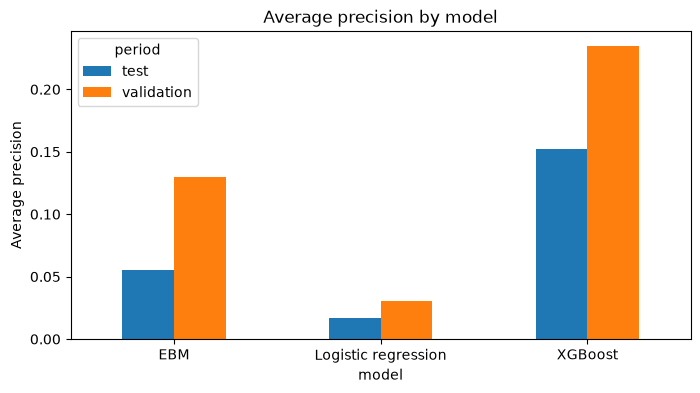

Validation-selected threshold for XGBoost : 0.3486


,no alert,alert
actual normal,430138,480
actual laundering,371,117


Highest-scored reporting-period transactions (examples, not a metric):


,timestamp,amount_paid,payment_currency,amount_received,receiving_currency,payment_format,label,model_score
2504920,2022-09-10 15:21:00,73798.52,Saudi Riyal,73798.52,Saudi Riyal,ACH,1,0.819063
2355442,2022-09-09 17:57:00,14235.23,Canadian Dollar,14235.23,Canadian Dollar,ACH,0,0.818984
2488576,2022-09-10 11:13:00,19756.19,Saudi Riyal,19756.19,Saudi Riyal,ACH,1,0.795916
2282203,2022-09-09 12:28:00,44646.93,Saudi Riyal,44646.93,Saudi Riyal,ACH,1,0.726030
2506877,2022-09-10 15:51:00,47138.78,Saudi Riyal,47138.78,Saudi Riyal,ACH,1,0.726030
2272285,2022-09-09 11:43:00,16399.75,US Dollar,16399.75,US Dollar,ACH,1,0.698202
2217830,2022-09-09 07:40:00,11748.04,US Dollar,11748.04,US Dollar,ACH,0,0.698202
2482593,2022-09-10 09:45:00,16530.28,US Dollar,16530.28,US Dollar,ACH,1,0.698202
2256870,2022-09-09 10:34:00,14256.91,Euro,14256.91,Euro,ACH,0,0.697377
2280233,2022-09-09 12:19:00,15864.02,Euro,15864.02,Euro,ACH,1,0.697377


In [6]:
rows = []
scores = {}
thresholds = {}
for name, model in models.items():
    validation_score = model.predict_proba(X_validation)[:, 1]
    precision_curve, recall_curve, cutoff_values = precision_recall_curve(
        y_validation, validation_score
    )
    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    )
    thresholds[name] = cutoff_values[np.argmax(f1_curve)]

    for period, X, y in [
        ("validation", X_validation, y_validation),
        ("test", X_test, y_test),
    ]:
        score = validation_score if period == "validation" else model.predict_proba(X)[:, 1]
        scores[(name, period)] = score
        alerts = score >= thresholds[name]
        rows.append({
            "model": name,
            "period": period,
            "average_precision": average_precision_score(y, score),
            "roc_auc": roc_auc_score(y, score),
            "precision": precision_score(y, alerts, zero_division=0),
            "recall": recall_score(y, alerts),
            "f1": f1_score(y, alerts),
            "alerts": int(alerts.sum()),
        })
results = pd.DataFrame(rows)
selected_model = (
    results[results["period"] == "validation"]
    .sort_values("average_precision", ascending=False)
    .iloc[0]["model"]
)
print("Selected using validation AP:", selected_model)
print("Positive-label rate: validation", round(y_validation.mean(), 4),
      "reporting period", round(y_test.mean(), 4))
display(results.round(4))
results.pivot(index="model", columns="period", values="average_precision").plot.bar(
    figsize=(8, 4), title="Average precision by model"
)
plt.ylabel("Average precision")
plt.xticks(rotation=0)
plt.show()

selected_alerts = scores[(selected_model, "test")] >= thresholds[selected_model]
print("Validation-selected threshold for", selected_model, ":", round(thresholds[selected_model], 4))
display(pd.DataFrame(
    confusion_matrix(y_test, selected_alerts),
    index=["actual normal", "actual laundering"],
    columns=["no alert", "alert"],
))

top = np.argsort(-scores[(selected_model, "test")])[:10]
top_transactions = test.iloc[top][[
    "timestamp", "amount_paid", "payment_currency", "amount_received",
    "receiving_currency", "payment_format", "label"
]].copy()
top_transactions["model_score"] = scores[(selected_model, "test")][top]
print("Highest-scored reporting-period transactions (examples, not a metric):")
display(top_transactions)

## 7. Explain what the models learned

The logistic coefficients and EBM terms are **global** summaries. XGBoost's native Tree SHAP values explain one high-scored test row; these values add to the model's raw log-odds score. Explanations describe model behavior, not proof of laundering.

In [7]:
logistic = models["Logistic regression"].named_steps["logisticregression"]
coefficients = pd.Series(logistic.coef_[0], index=X_train.columns)
print("Logistic regression: largest coefficients")
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(10))

xgboost = models["XGBoost"]
most_flagged = np.argmax(scores[("XGBoost", "test")])
contributions = xgboost.get_booster().predict(
    DMatrix(X_test.iloc[[most_flagged]]), pred_contribs=True
)[0][:-1]
shap_values = pd.Series(contributions, index=X_train.columns)
print("XGBoost Tree SHAP: largest contributions for one high-scored row")
display(shap_values.reindex(shap_values.abs().sort_values(ascending=False).index).head(10))

ebm = models["EBM"]
ebm_terms = pd.Series(ebm.term_importances(), index=ebm.term_names_)
print("EBM: most important global terms")
display(ebm_terms.sort_values(ascending=False).head(10))

Logistic regression: largest coefficients


prior_pair_count              -1.756914
payment_format_ACH             1.098383
same_account                  -0.747513
prior_sender_count             0.590174
payment_format_Wire           -0.373926
same_bank                     -0.310925
payment_format_Reinvestment   -0.297737
payment_format_Cheque         -0.258923
log_amount                     0.220448
log_amount_received            0.187247
dtype: float32

XGBoost Tree SHAP: largest contributions for one high-scored row


payment_format_ACH                3.230170
payment_currency_Saudi Riyal      0.862424
prior_receiver_count              0.523798
prior_pair_count                  0.503875
receiving_currency_Saudi Riyal    0.501785
prior_sender_count                0.340612
log_amount_received               0.195544
log_amount                        0.183436
hour                              0.121213
same_account                      0.021287
dtype: float32

EBM: most important global terms


prior_pair_count               1.338877
payment_format_ACH             0.814571
prior_sender_count             0.596940
payment_format_Cheque          0.450339
same_account                   0.428105
prior_receiver_count           0.350800
payment_format_Credit Card     0.341216
log_amount_received            0.329571
log_amount                     0.326359
payment_format_Reinvestment    0.296117
dtype: float64

## 8. What this MVP can claim

This notebook demonstrates a **time-based comparison of three models on sampled synthetic transactions**. The sender, receiver, and pair history features see only sampled earlier transactions, so they understate complete account activity. All raw transaction fields are read; account and bank IDs remain available in `transactions` and are represented to the model through history and relationship features. They help capture part of the transaction network, but this is not the full graph modeling used in the [original IBM study](https://papers.nips.cc/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf). Its published F1 scores use a different feature pipeline and split, so they are not directly comparable with this notebook.

An exploratory XGBoost check helps explain the gain: at 50% sampling and positive-class weight 10, the previous simple features gave validation AP **0.0602**; adding earlier receiver and sender–receiver counts raised it to **0.2164**; adding the extra current-transaction fields raised it to **0.2349**. Doubling the old sample alone, while keeping the old features and weight, barely changed reporting-period AP (**0.0366** to **0.0367**). More rows alone were not the main fix.

The September 11–18 data has a sharp volume and label-rate shift and is excluded. We also looked at the September 9–10 results while improving this MVP, so those results are **exploratory**, not an untouched final estimate. Class weighting helps with rare labels, but scores are **not calibrated probabilities**. The figures are educational, not operational AML validation. The CSV has no investigator decisions or SAR outcomes, so this notebook cannot evaluate those outcomes. Databricks and dbt remain possible future data-engineering tools, as described in the [project guide](docs/PROJECT_GUIDE.md).

### How this relates to bank AML monitoring

Banks may combine transaction reports, rules, intelligent surveillance, and referrals to create alerts. Investigators examine customer and transaction context before deciding whether activity warrants a Suspicious Activity Report. The [FFIEC BSA/AML Examination Manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes these steps and notes that monitoring depends on each bank's risks. Current [Federal Reserve model-risk guidance](https://www.federalreserve.gov/frrs/guidance/supervisory-guidance-on-model-risk-management.htm) includes out-of-time testing and ongoing monitoring among sound practices. The guidance reviewed here does not prescribe a universal metric list or require every raw field to be a direct predictor. The [2026 interagency model-risk guidance](https://www.federalreserve.gov/supervisionreg/srletters/SR2602a1.pdf) calls for input and testing choices aligned with the model’s purpose. Our three-model comparison covers model scoring and synthetic-label alerts only.